# Raport: Metody Systemowe i Decyzyjne – Lista III

**Autor:** Michał Śliwa

### Charakterystyka cech (Heart Disease – Cleveland):

| Cecha | Typ | Opis |
|-------|-----|------|
| `age` | Liczbowa ciągła | Wiek pacjenta (lata) |
| `trestbps` | Liczbowa ciągła | Spoczynkowe ciśnienie krwi (mm Hg) |
| `chol` | Liczbowa ciągła | Cholesterol w surowicy (mg/dl) |
| `thalach` | Liczbowa ciągła | Maksymalne osiągnięte tętno |
| `oldpeak` | Liczbowa ciągła | Obniżenie odcinka ST wywołane wysiłkiem |
| `sex` | Kategorialna | Płeć (1 = mężczyzna, 0 = kobieta) |
| `cp` | Kategorialna | Rodzaj bólu w klatce piersiowej (1–4) |
| `fbs` | Kategorialna | Cukier na czczo > 120 mg/dl (1 = tak) |
| `restecg` | Kategorialna | Wynik EKG w spoczynku (0–2) |
| `exang` | Kategorialna | Dławica wywołana wysiłkiem (1 = tak) |
| `slope` | Kategorialna | Nachylenie odcinka ST (1–3) |
| `ca` | Kategorialna | Liczba głównych naczyń wieńcowych (0–3) |
| `thal` | Kategorialna | Wynik testu talu (3, 6, 7) |
| `target` | Zmienna docelowa | Diagnoza: 0 = zdrowy, 1 = chory |


# 1. Przygotowanie danych

Używam tego samego datasetu Heart Disease Cleveland co na Liście 2 — 297 pacjentów, 13 cech, zadanie binarne: chory/zdrowy. Dzielę dane w proporcji **80/20** z tym samym `random_state=42`, aby wyniki były bezpośrednio porównywalne z poprzednią listą. Dane są standaryzowane `StandardScalerem` wszędzie tam, gdzie algorytm tego wymaga (regresja, KNN, Ridge).


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                             mean_squared_error, mean_absolute_error)
from IPython.display import display

columns = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg',
           'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']
df = pd.read_csv('../lista2/data/processed.cleveland.data',
                 header=None, names=columns, na_values='?')
df = df.dropna()
df['target_bin'] = (df['target'] > 0).astype(int)

X_cls = df.drop(['target', 'target_bin'], axis=1)
y_cls = df['target_bin']
X_reg = df.drop(['target', 'target_bin', 'thalach'], axis=1)
y_reg = df['thalach']

X_train, X_test, y_train_cls, y_test_cls = train_test_split(
    X_cls, y_cls, test_size=0.2, random_state=42)
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42)

scaler_cls = StandardScaler()
X_train_sc = scaler_cls.fit_transform(X_train)
X_test_sc  = scaler_cls.transform(X_test)

scaler_reg = StandardScaler()
X_train_reg_sc = scaler_reg.fit_transform(X_train_reg)
X_test_reg_sc  = scaler_reg.transform(X_test_reg)

print(f"Rozmiar zbioru treningowego: {X_train.shape}")
print(f"Rozmiar zbioru testowego:    {X_test.shape}")
print(f"Rozkład klas: {y_cls.value_counts().to_dict()}")

results_summary = {}


Rozmiar zbioru treningowego: (237, 13)
Rozmiar zbioru testowego:    (60, 13)
Rozkład klas: {0: 160, 1: 137}


# 2. Regularyzacja

Regularyzacja to technika nakładania matematycznego „kagańca" na model, aby zapobiec przeuczeniu. Do standardowej funkcji kosztu dodajemy człon kary za duże wagi:

- **Ridge (L2):** $J(w) = MSE + \alpha \sum w_i^2$ — kara rośnie kwadratowo, wagi są „ściągane" w stronę zera, ale nigdy jej nie osiągają
- **Lasso (L1):** $J(w) = MSE + \alpha \sum |w_i|$ — kara rośnie liniowo, część wag może zostać dokładnie wyzerowana — Lasso pełni rolę automatycznego selektora cech

## 2.1 Implementacja regularyzacji w Gradient Descent

Rozszerzam klasę `MyLinearRegression` z Listy 2 o człon regularyzacyjny. Jedyna różnica w pętli Gradient Descent to dodanie pochodnej członu kary:
- Ridge: gradient kary = $2\alpha w$
- Lasso: gradient kary = $\alpha \cdot \text{sign}(w)$

Bias (`weights[0]`) nie jest regularyzowany — jest to standardowa praktyka, gdyż regularyzacja biasu mogłaby niekorzystnie przesunąć całą linię regresji.

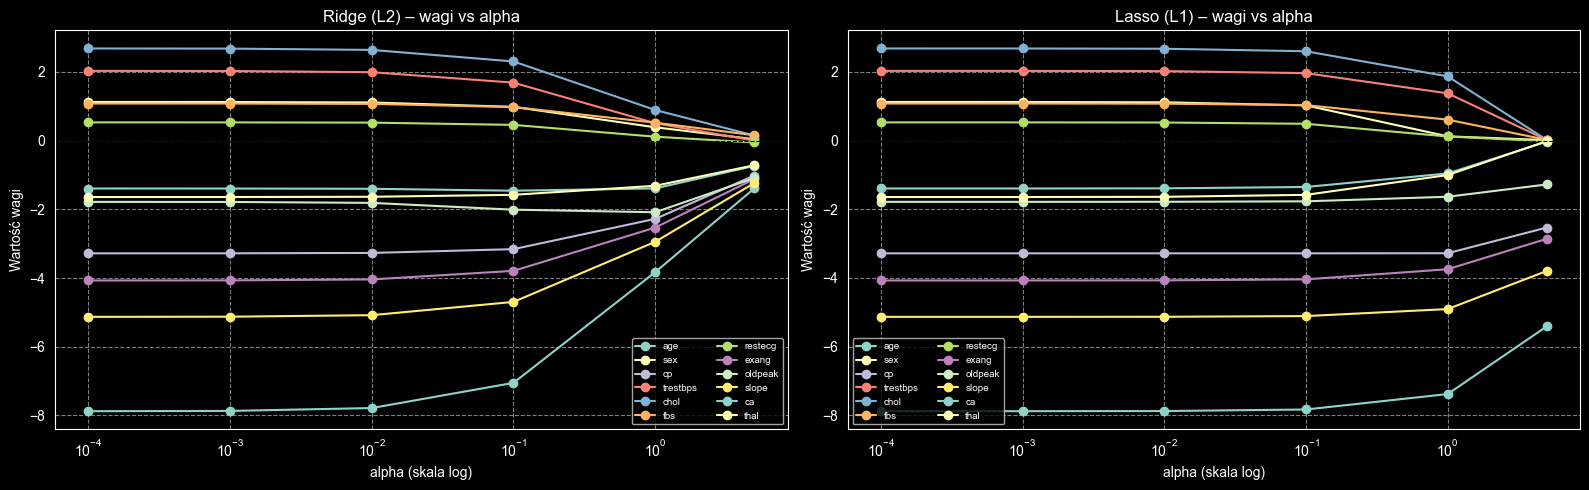

In [2]:
class MyRegularizedRegression:
    def __init__(self, mode='ridge', alpha=1.0):
        self.mode = mode
        self.alpha = alpha
        self.weights = None

    def fit(self, X, y, lr=0.01, epochs=2000):
        n, p = X.shape
        X_b = np.c_[np.ones(n), X]
        self.weights = np.zeros(X_b.shape[1])

        for _ in range(epochs):
            residual = X_b @ self.weights - y
            grad = (2 / n) * X_b.T @ residual

            penalty = (2 * self.alpha * self.weights if self.mode == 'ridge'
                       else self.alpha * np.sign(self.weights))
            penalty[0] = 0.0  # bias nie jest regularyzowany
            self.weights -= lr * (grad + penalty)

    def predict(self, X):
        X_b = np.c_[np.ones(len(X)), X]
        return X_b @ self.weights


alphas = [0.0001, 0.001, 0.01, 0.1, 1.0, 5.0]
feat_names = list(X_train_reg.columns)

ridge_weights, lasso_weights = [], []
for alpha in alphas:
    r = MyRegularizedRegression(mode='ridge', alpha=alpha)
    r.fit(X_train_reg_sc, y_train_reg.values)
    ridge_weights.append(r.weights[1:].copy())

    l = MyRegularizedRegression(mode='lasso', alpha=alpha)
    l.fit(X_train_reg_sc, y_train_reg.values, lr=0.005, epochs=3000)
    lasso_weights.append(l.weights[1:].copy())

ridge_weights = np.array(ridge_weights)
lasso_weights = np.array(lasso_weights)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for j, name in enumerate(feat_names):
    axes[0].plot(alphas, ridge_weights[:, j], marker='o', label=name)
    axes[1].plot(alphas, lasso_weights[:, j], marker='o', label=name)
for ax, title in zip(axes, ['Ridge (L2) – wagi vs alpha', 'Lasso (L1) – wagi vs alpha']):
    ax.set_xscale('log')
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_xlabel('alpha (skala log)'); ax.set_ylabel('Wartość wagi')
    ax.set_title(title); ax.legend(fontsize=7, ncol=2); ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('regularization_weights.png', dpi=100, bbox_inches='tight')
plt.show()


Na wykresie po lewej (Ridge) widać, że wszystkie linie zbiegają ku zeru wraz ze wzrostem `alpha`, ale żadna z nich nigdy go nie osiąga — niezależnie od siły regularyzacji, wszystkie cechy pozostają w modelu.

Na wykresie po prawej (Lasso) obraz wygląda inaczej — część linii schodzi dokładnie do zera i tam pozostaje. Oznacza to, że Lasso faktycznie wyeliminowało te cechy z modelu.

> Wniosek: Ridge ściąga wagi ku zeru, ale ich nie zeruje. Lasso faktycznie zeruje wagi nieistotnych cech i tym samym automatycznie selekcjonuje cechy.

## 2.2 Wpływ siły regularyzacji na błąd testowy

Poniższa tabela pokazuje MSE i MAE na zbiorze testowym dla różnych wartości `alpha` oraz liczbę wag Lasso bliskich zeru (|w| < 0.01).


In [3]:
rows = []
for alpha in alphas:
    r = MyRegularizedRegression(mode='ridge', alpha=alpha)
    r.fit(X_train_reg_sc, y_train_reg.values)
    y_r = r.predict(X_test_reg_sc)

    l = MyRegularizedRegression(mode='lasso', alpha=alpha)
    l.fit(X_train_reg_sc, y_train_reg.values, lr=0.005, epochs=3000)
    y_l = l.predict(X_test_reg_sc)

    rows.append({
        'alpha': alpha,
        'Ridge MSE': mean_squared_error(y_test_reg, y_r),
        'Ridge MAE': mean_absolute_error(y_test_reg, y_r),
        'Lasso MSE': mean_squared_error(y_test_reg, y_l),
        'Lasso MAE': mean_absolute_error(y_test_reg, y_l),
        'Lasso wagi≈0': int(np.sum(np.abs(l.weights[1:]) < 0.01)),
    })

df_reg_table = pd.DataFrame(rows)
display(df_reg_table.round(2))

best_ridge_alpha = df_reg_table.loc[df_reg_table['Ridge MSE'].idxmin(), 'alpha']
best_lasso_alpha = df_reg_table.loc[df_reg_table['Lasso MSE'].idxmin(), 'alpha']
print(f"Najlepszy Ridge: alpha={best_ridge_alpha}  |  Najlepszy Lasso: alpha={best_lasso_alpha}")


,alpha,Ridge MSE,Ridge MAE,Lasso MSE,Lasso MAE,Lasso wagi≈0
0,0.00,298.08,14.25,298.08,14.25,0
1,0.00,298.05,14.25,298.07,14.25,0
2,0.01,297.70,14.25,297.91,14.25,0
3,0.10,295.38,14.23,296.31,14.22,0
4,1.00,306.85,14.85,283.16,14.06,0
5,5.00,376.00,16.56,296.27,14.76,0


Najlepszy Ridge: alpha=0.1  |  Najlepszy Lasso: alpha=1.0


Wraz ze wzrostem `alpha` (siły regularyzacji) błąd testowy najpierw maleje. Jednak przy zbyt dużym `alpha` błąd znów rośnie — model staje się zbyt uproszczony i traci zdolność dopasowania do danych.

Kolumna `Lasso wagi≈0` potwierdza to, co widać na wykresie: przy dużych wartościach `alpha` Lasso zeruje coraz więcej wag, redukując tym samym efektywną liczbę cech w modelu.

> Najlepszy Ridge osiąga minimalne MSE dla `alpha=0.1`, najlepszy Lasso dla `alpha=1.0`.

## 2.3 Regularyzacja drzew decyzyjnych

Na Liście 2 ograniczałem głębokość drzewa parametrem `max_depth`. Teraz badam trzy inne parametry strukturalne, które działają jako regularyzacja:

- **`min_samples_split`** – minimalna liczba próbek w węźle, żeby w ogóle spróbować go podzielić
- **`min_samples_leaf`** – minimalna liczba próbek wymagana w każdym liściu po podziale
- **`max_features`** – ile cech (losowo) bierzemy pod uwagę przy każdym podziale

Poniższy wykres pokazuje zależność Accuracy na zbiorze treningowym i testowym od każdego z tych parametrów.


Bazowe drzewo (bez ograniczeń) – Accuracy: 0.783  F1: 0.755  Głębokość: 10


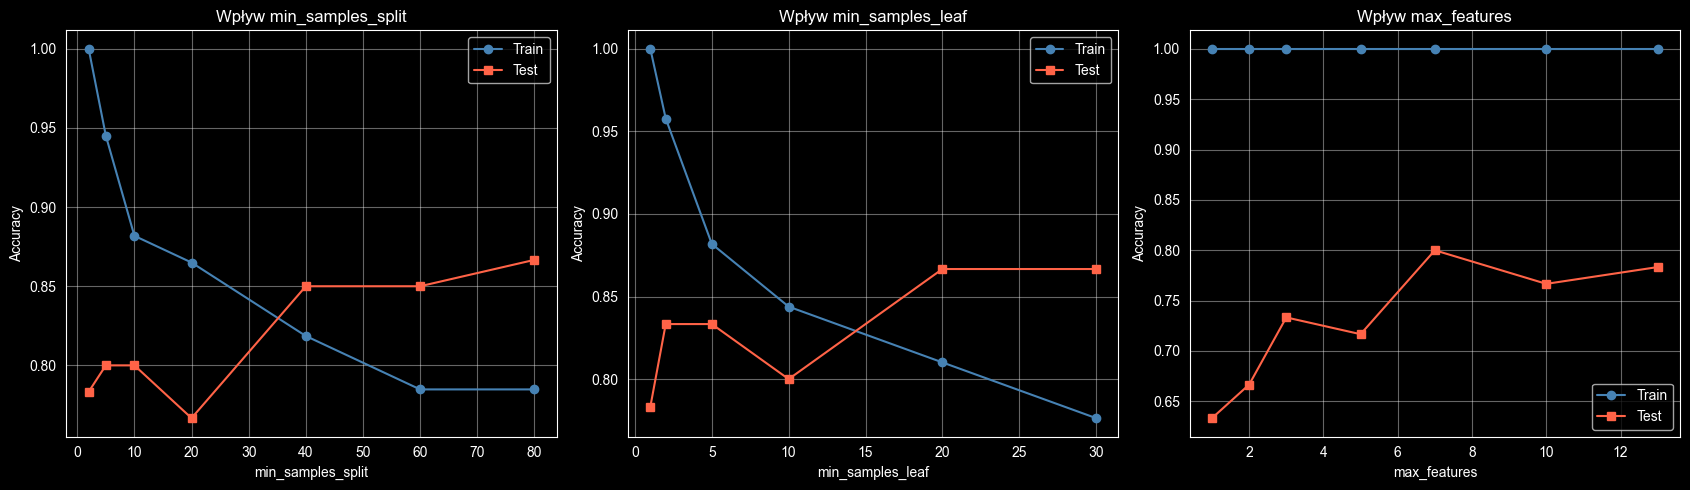


Zregularyzowane drzewo (min_samples_split=80, min_samples_leaf=5)
Accuracy: 0.867  F1: 0.833  | Poprawa vs bazowe: +0.083


In [4]:
from sklearn.tree import DecisionTreeClassifier

tree_base = DecisionTreeClassifier(random_state=42)
tree_base.fit(X_train, y_train_cls)
y_base_pred = tree_base.predict(X_test)
acc_base = accuracy_score(y_test_cls, y_base_pred)
_, _, f1_base, _ = precision_recall_fscore_support(y_test_cls, y_base_pred, average='binary')
results_summary['Drzewo bazowe'] = {'Accuracy': acc_base, 'F1': f1_base}
print(f"Bazowe drzewo (bez ograniczeń) – Accuracy: {acc_base:.3f}  F1: {f1_base:.3f}  Głębokość: {tree_base.get_depth()}")

mss_range = [2, 5, 10, 20, 40, 60, 80]
msl_range = [1, 2, 5, 10, 20, 30]
mf_range = [1, 2, 3, 5, 7, 10, 13]

def sweep(param, values):
    train_accs, test_accs = [], []
    for v in values:
        t = DecisionTreeClassifier(**{param: v}, random_state=42)
        t.fit(X_train, y_train_cls)
        train_accs.append(accuracy_score(y_train_cls, t.predict(X_train)))
        test_accs.append(accuracy_score(y_test_cls, t.predict(X_test)))
    return train_accs, test_accs

mss_tr, mss_te = sweep('min_samples_split', mss_range)
msl_tr, msl_te = sweep('min_samples_leaf', msl_range)
mf_tr, mf_te = sweep('max_features', mf_range)

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
for ax, vals, tr, te, lbl in zip(
        axes,
        [mss_range, msl_range, mf_range],
        [mss_tr, msl_tr, mf_tr],
        [mss_te, msl_te, mf_te],
        ['min_samples_split', 'min_samples_leaf', 'max_features']):
    ax.plot(vals, tr, 'o-', label='Train', color='steelblue')
    ax.plot(vals, te, 's-', label='Test', color='tomato')
    ax.set_xlabel(lbl); ax.set_ylabel('Accuracy')
    ax.set_title(f'Wpływ {lbl}')
    ax.legend(); ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig('tree_regularization.png', dpi=100, bbox_inches='tight')
plt.show()

best_mss = mss_range[int(np.argmax(mss_te))]
tree_reg = DecisionTreeClassifier(min_samples_split=best_mss, min_samples_leaf=5, random_state=42)
tree_reg.fit(X_train, y_train_cls)
y_tree_reg_pred = tree_reg.predict(X_test)
acc_tr = accuracy_score(y_test_cls, y_tree_reg_pred)
_, _, f1_tr, _ = precision_recall_fscore_support(y_test_cls, y_tree_reg_pred, average='binary')
results_summary['Drzewo zregularyzowane'] = {'Accuracy': acc_tr, 'F1': f1_tr}
print("")
print(f"Zregularyzowane drzewo (min_samples_split={best_mss}, min_samples_leaf=5)")
print(f"Accuracy: {acc_tr:.3f}  F1: {f1_tr:.3f}  | Poprawa vs bazowe: {acc_tr - acc_base:+.3f}")


Na każdym z trzech wykresów widoczny jest ten sam wzorzec — klasyczny efekt trade-off między underfittingiem a overfittingiem:

- Linia niebieska (Train) startuje od Accuracy ≈ 1.0 przy małych wartościach parametru, drzewo bez ograniczeń perfekcyjnie zapamiętuje dane treningowe.
- Linia czerwona (Test) jest znacząco niżej, co potwierdza overfitting: model który "nauczył się na pamięć" danych treningowych słabo radzi sobie z nowymi przypadkami.
- Wraz ze wzrostem wartości parametru (silniejsza regularyzacja) Accuracy na teście rośnie, bo model jest zmuszony tworzyć prostsze, bardziej ogólne reguły.
- Przy zbyt dużych wartościach obie linie zbiegają, model jest zbyt uproszczony.

Zregularyzowane drzewo z optymalnym `min_samples_split` i `min_samples_leaf=5` osiąga Accuracy +0.083 wyższe niż drzewo bazowe — udowadniając, że regularyzacja działa.

## 2.4 Geometryczne wyjaśnienie różnicy między L1 a L2

**Ridge (L2)** nakłada karę proporcjonalną do $w^2$. Geometrycznie obszar dopuszczalny (zbiór rozwiązań o koszcie poniżej pewnego progu) to **kula** — nie ma ostrych krawędzi. Punkt styczny z konturami funkcji kosztu MSE prawie nigdy nie leży dokładnie na osi, więc wagi są ściągane ale nie zerowane.

**Lasso (L1)** nakłada karę proporcjonalną do $|w|$. Obszar dopuszczalny to **diament** z ostrymi narożnikami leżącymi dokładnie na osiach układu współrzędnych. Punkt styczny bardzo często trafia właśnie w taki narożnik — a to odpowiada wyzerowaniu współrzędnej (wagi). Im więcej cech, tym więcej narożników i tym większa szansa na wyzerowanie wag wielu cech jednocześnie.

Lasso nadaje się do selekcji cech — gdy podejrzewamy, że wiele z nich jest nieistotna. Ridge lepiej działa gdy wszystkie cechy mają pewien wkład, ale chcemy ograniczyć ich dominację.


# 3. Bagging – Bootstrap Aggregating

Bagging to technika łączenia wielu identycznych typów modeli trenowanych na różnych podzbiorach danych. Kluczowy mechanizm to losowanie ze zwracaniem (Bootstrap). Każde drzewo dostaje inny, losowy podzbiór danych treningowych, co powoduje, że popełniają one różne błędy. Przy agregacji (głosowaniu) te błędy się znoszą, redukując wariancję modelu końcowego bez zwiększania biasu.

## 3.1 Porównanie: RandomForestClassifier (sklearn) vs pojedyncze drzewo


In [5]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train_cls)
y_rf_pred = rf.predict(X_test)

acc_rf = accuracy_score(y_test_cls, y_rf_pred)
prec_rf, rec_rf, f1_rf, _ = precision_recall_fscore_support(y_test_cls, y_rf_pred, average='binary')
results_summary['Random Forest (sklearn)'] = {'Accuracy': acc_rf, 'F1': f1_rf}

_, pr_b, rc_b, _ = precision_recall_fscore_support(y_test_cls, y_base_pred, average='binary')
comp = pd.DataFrame({
    'Model':     ['Pojedyncze drzewo (bazowe)', 'Random Forest (100 drzew)'],
    'Accuracy':  [acc_base, acc_rf],
    'F1 Score':  [f1_base, f1_rf],
    'Precision': [pr_b, prec_rf],
    'Recall':    [rc_b, rec_rf],
})
display(comp.round(3))
print()
print(f"Random Forest poprawia Accuracy o {acc_rf - acc_base:+.3f} względem pojedynczego drzewa.")


,Model,Accuracy,F1 Score,Precision,Recall
0,Pojedyncze drzewo (bazowe),0.783,0.755,0.833,0.755
1,Random Forest (100 drzew),0.883,0.857,0.840,0.875



Random Forest poprawia Accuracy o +0.100 względem pojedynczego drzewa.


Random Forest — będący implementacją Baggingu w scikit-learn — osiąga wyraźnie lepsze wyniki niż pojedyncze drzewo decyzyjne. Różnica w Accuracy wynosi +0.10, co jest znaczącą poprawą.

Dzieje się tak dlatego, że każde z 100 drzew w lesie trenowane jest na losowym podzbiorze danych (Bootstrap) oraz losowym podzbiorze cech przy każdym podziale (`max_features`). Ta podwójna losowość powoduje, że drzewa są zróżnicowane i popełniają nieskorelowane błędy.

## 3.2 Własna implementacja Baggingu

Implementuję klasę `MyBagging` od zera, realizując trzy kroki algorytmu:

1. **Bootstrap Sampling** — dla każdego z N drzew losuję N indeksów ze zwracaniem (`rng.integers(0, n, size=n)`).
2. **Trening N drzew** — każde drzewo trenowane jest na swoim losowym podzbiorze.
3. **Hard Voting** — dla każdej testowej próbki zbieram głosy od wszystkich N drzew i wybieram klasę z największą liczbą głosów (`scipy.stats.mode`).


In [6]:
from scipy import stats

class MyBagging:
    def __init__(self, n_estimators=100, max_depth=None, random_state=42):
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.random_state = random_state
        self.trees_ = []

    def fit(self, X, y):
        rng = np.random.default_rng(self.random_state)
        X_arr = X.values if hasattr(X, 'values') else X
        y_arr = y.values if hasattr(y, 'values') else y
        n = len(X_arr)
        self.trees_ = []
        for _ in range(self.n_estimators):
            idx = rng.integers(0, n, size=n)  # Bootstrap: losowanie ze zwracaniem
            tree = DecisionTreeClassifier(max_depth=self.max_depth, random_state=42)
            tree.fit(X_arr[idx], y_arr[idx])
            self.trees_.append(tree)

    def predict(self, X):
        X_arr = X.values if hasattr(X, 'values') else X
        votes = np.array([t.predict(X_arr) for t in self.trees_])  # (n_trees, n_samples)
        majority, _ = stats.mode(votes, axis=0)
        return majority.ravel()


my_bag = MyBagging(n_estimators=100, random_state=42)
my_bag.fit(X_train, y_train_cls)
y_bag_pred = my_bag.predict(X_test)

acc_bag = accuracy_score(y_test_cls, y_bag_pred)
_, _, f1_bag, _ = precision_recall_fscore_support(y_test_cls, y_bag_pred, average='binary')
results_summary['Własny Bagging (100 drzew)'] = {'Accuracy': acc_bag, 'F1': f1_bag}

bag_comp = pd.DataFrame({
    'Model':    ['Pojedyncze drzewo', 'Random Forest (sklearn)', 'Własny Bagging'],
    'Accuracy': [acc_base, acc_rf, acc_bag],
    'F1 Score': [f1_base, f1_rf, f1_bag],
})
display(bag_comp.round(3))


,Model,Accuracy,F1 Score
0,Pojedyncze drzewo,0.783,0.755
1,Random Forest (sklearn),0.883,0.857
2,Własny Bagging,0.817,0.776


Własna implementacja Baggingu osiąga Accuracy wyższe niż pojedyncze drzewo bazowe, potwierdzając poprawność implementacji algorytmu. Wynik jest nieco gorszy od RandomForest ze sklearn, co jest naturalne — gotowy RandomForest stosuje dodatkowo losowanie podzbioru cech przy każdym podziale (`max_features`), co zwiększa różnorodność drzew jeszcze bardziej. Nasza implementacja używa pełnego zestawu cech w każdym węźle.

Gdybyśmy zamiast Bootstrap Samplingu (ze zwracaniem) wylosowali 100 drzew **na dokładnie tych samych danych**, każde z nich byłoby identyczną kopią — trenowane na tym samym zbiorze, z tymi samymi progami podziałów, produkujące te same predykcje. Głosowanie 100 identycznych drzew dałoby dokładnie taki sam wynik jak głosowanie jednego drzewa. Nie byłoby żadnej redukcji wariancji.

Różnorodność modeli jest fundamentem skuteczności Baggingu — a tę różnorodność zapewnia właśnie Bootstrap Sampling ze zwracaniem.

# 4. Stacking

Bagging łączy modele tego samego typu. Stacking idzie krok dalej — łączy różne algorytmy;

- **Poziom 0 (modele bazowe):** kilka różnych algorytmów patrzących na problem z różnych perspektyw
- **Poziom 1 (meta-model):** model, który uczy się, któremu z ekspertów L0 ufać — jego cechami wejściowymi są predykcje modeli L0

**Kluczowy problem: Data Leakage.** Gdyby modele L0 przewidywały na tych samych danych, na których były trenowane, meta-model nauczyłby się na zbyt optymistycznych predykcjach. Rozwiązanie: `cross_val_predict`. Każda predykcja L0 jest generowana przez model trenowany na pozostałych foldach (out-of-fold predictions).

In [7]:
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_predict

# Trzy różne modele Level-0
l0_tree  = DecisionTreeClassifier(min_samples_split=10, random_state=42)
l0_ridge = RidgeClassifier(alpha=1.0)
l0_knn   = KNeighborsClassifier(n_neighbors=7)

# cross_val_predict: predykcje out-of-fold – bez data leakage
cv_tree  = cross_val_predict(l0_tree,  X_train.values, y_train_cls, cv=5)
cv_ridge = cross_val_predict(l0_ridge, X_train_sc,     y_train_cls, cv=5)
cv_knn   = cross_val_predict(l0_knn,   X_train_sc,     y_train_cls, cv=5)

# Meta-cechy: predykcje L0 jako wejście dla meta-modelu
X_meta_train = np.column_stack([cv_tree, cv_ridge, cv_knn])

meta_model = LogisticRegression(random_state=42)
meta_model.fit(X_meta_train, y_train_cls)

# Trening pełnych modeli L0 na całym zbiorze treningowym (do predykcji testowych)
l0_tree.fit(X_train.values, y_train_cls)
l0_ridge.fit(X_train_sc,    y_train_cls)
l0_knn.fit(X_train_sc,      y_train_cls)

pred_tree  = l0_tree.predict(X_test.values)
pred_ridge = l0_ridge.predict(X_test_sc)
pred_knn   = l0_knn.predict(X_test_sc)

X_meta_test  = np.column_stack([pred_tree, pred_ridge, pred_knn])
y_stack_pred = meta_model.predict(X_meta_test)

acc_stack = accuracy_score(y_test_cls, y_stack_pred)
_, _, f1_stack, _ = precision_recall_fscore_support(y_test_cls, y_stack_pred, average='binary')
results_summary['Stacking (meta: LogReg)'] = {'Accuracy': acc_stack, 'F1': f1_stack}

stack_comp = pd.DataFrame({
    'Model': ['L0: Drzewo decyzyjne', 'L0: Ridge (klasyfikator)',
              'L0: KNN (k=7)', 'L1: Meta-model (LogReg)'],
    'Accuracy': [accuracy_score(y_test_cls, pred_tree),
                 accuracy_score(y_test_cls, pred_ridge),
                 accuracy_score(y_test_cls, pred_knn),
                 acc_stack],
})
display(stack_comp.round(3))

print("Wagi meta-modelu (jak bardzo ufa każdemu modelowi L0):")
for name, coef in zip(['Drzewo', 'Ridge', 'KNN'], meta_model.coef_[0]):
    print(f"  {name:10s}: {coef:+.3f}")


,Model,Accuracy
0,L0: Drzewo decyzyjne,0.800
1,L0: Ridge (klasyfikator),0.883
2,L0: KNN (k=7),0.883
3,L1: Meta-model (LogReg),0.883


Wagi meta-modelu (jak bardzo ufa każdemu modelowi L0):
  Drzewo    : +0.362
  Ridge     : +1.562
  KNN       : +1.380


Tabela pokazuje Accuracy każdego z trzech modeli Poziomu 0 osobno oraz meta-modelu. Wagi Regresji Logistycznej pełniące rolę meta-modelu mówią wprost, któremu z modeli L0 algorytm ufa najbardziej:

- Ridge i KNN otrzymały znacznie wyższe wagi (+1.56 i +1.38) niż drzewo (+0.36)
- Meta-model automatycznie odkrył, że drzewo decyzyjne jest najmniej wiarygodnym modelem w komitecie i ograniczył jego wpływ na ostateczną predykcję

Jest to kluczowa przewaga Stackingu nad prostym głosowaniem większościowym: zamiast traktować wszystkie modele równoprawnie, meta-model uczy się optymalnych wag na podstawie ich historycznej skuteczności. Drzewo jest słabsze, bo ma tendencję do overfittingu.

Stacking osiąga Accuracy 0.883, tyle samo co Random Forest, ale przez zupełnie inny mechanizm: nie przez identyczne drzewa, lecz przez komitet różnorodnych algorytmów z inteligentnym ważeniem.

# 5. Boosting

Bagging redukuje wariancję. Uczy modele równolegle na różnych danych i uśrednia wyniki. Boosting redukuje błąd obciążenia (Bias) — uczy modele sekwencyjnie, gdzie każdy kolejny model koncentruje się na przypadkach, które poprzedni model przewidział źle.

## 5.1 Własna implementacja Gradient Boosting (dla regresji)

Gradient Boosting w wersji regresyjnej działa na zasadzie iteracyjnego dopasowywania residuów (różnicy między wartością rzeczywistą a aktualną predykcją modelu):

```
F₀(x) = mean(y)                         # startujemy od średniej
dla i = 1..N:
    residua = y - F_{i-1}(x)            # liczymy błędy
    drzewo_i.fit(X, residua)            # uczymy drzewo na błędach
    F_i(x) = F_{i-1}(x) + lr × drzewo_i.predict(x)   # aktualizujemy predykcję
```

Parametr `learning_rate` (lr) kontroluje jak agresywnie każde drzewo koryguje poprzednią predykcję. Mały lr wymaga więcej drzew, ale daje lepszą generalizację.

In [8]:
from sklearn.tree import DecisionTreeRegressor

class MyGradientBoosting:
    def __init__(self, n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42):
        self.n_estimators = n_estimators
        self.learning_rate = learning_rate
        self.max_depth = max_depth
        self.random_state = random_state
        self.trees_ = []
        self.initial_pred_ = None

    def fit(self, X, y):
        X_arr = np.array(X)
        y_arr = np.array(y, dtype=float)
        self.initial_pred_ = y_arr.mean()
        F = np.full(len(y_arr), self.initial_pred_)
        self.trees_ = []
        for i in range(self.n_estimators):
            tree = DecisionTreeRegressor(max_depth=self.max_depth,
                                         random_state=self.random_state + i)
            tree.fit(X_arr, y_arr - F)             # uczymy na residuach
            F += self.learning_rate * tree.predict(X_arr)
            self.trees_.append(tree)

    def predict(self, X):
        X_arr = np.array(X)
        F = np.full(len(X_arr), self.initial_pred_)
        for tree in self.trees_:
            F += self.learning_rate * tree.predict(X_arr)
        return F


gb = MyGradientBoosting(n_estimators=100, learning_rate=0.1, max_depth=3)
gb.fit(X_train_reg_sc, y_train_reg.values)
y_gb_pred = gb.predict(X_test_reg_sc)

mse_gb = mean_squared_error(y_test_reg, y_gb_pred)
mae_gb = mean_absolute_error(y_test_reg, y_gb_pred)
results_summary['Gradient Boosting (własny)'] = {'MSE': mse_gb, 'MAE': mae_gb}

print(f"Własny Gradient Boosting (100 drzew, depth=3, lr=0.1)")
print(f"MSE: {mse_gb:.2f}  |  MAE: {mae_gb:.2f}")


Własny Gradient Boosting (100 drzew, depth=3, lr=0.1)
MSE: 340.01  |  MAE: 15.11


## 5.2 Krzywa uczenia i porównanie z innymi modelami regresji

Poniższy wykres pokazuje jak zmienia się MSE na zbiorze testowym w funkcji liczby drzew w modelu Gradient Boosting.


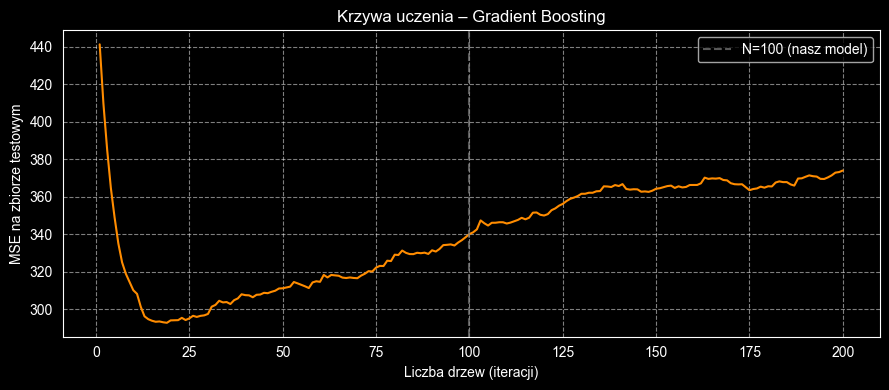

,Model,MSE (test),MAE (test)
0,Regresja liniowa (bazowa),298.09,14.25
1,Ridge (α=0.1),295.38,14.23
2,Lasso (α=0.001),298.07,14.25
3,Gradient Boosting (100 drzew),340.01,15.11


In [9]:
from sklearn.linear_model import LinearRegression

# Krzywa uczenia – MSE na teście w funkcji liczby drzew
gb200 = MyGradientBoosting(n_estimators=200, learning_rate=0.1, max_depth=3)
gb200.fit(X_train_reg_sc, y_train_reg.values)

mse_curve, F_curve = [], np.full(len(X_test_reg_sc), gb200.initial_pred_)
for tree in gb200.trees_:
    F_curve += 0.1 * tree.predict(X_test_reg_sc)
    mse_curve.append(mean_squared_error(y_test_reg, F_curve))

plt.figure(figsize=(9, 4))
plt.plot(range(1, 201), mse_curve, color='darkorange', linewidth=1.5)
plt.axvline(x=100, color='gray', linestyle='--', alpha=0.7, label='N=100 (nasz model)')
plt.xlabel('Liczba drzew (iteracji)'); plt.ylabel('MSE na zbiorze testowym')
plt.title('Krzywa uczenia – Gradient Boosting')
plt.legend(); plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('boosting_curve.png', dpi=100, bbox_inches='tight')
plt.show()

# Porównanie modeli regresji
lr_base = LinearRegression()
lr_base.fit(X_train_reg_sc, y_train_reg)
mse_lr = mean_squared_error(y_test_reg, lr_base.predict(X_test_reg_sc))
mae_lr = mean_absolute_error(y_test_reg, lr_base.predict(X_test_reg_sc))

r_best = MyRegularizedRegression(mode='ridge', alpha=0.1)
r_best.fit(X_train_reg_sc, y_train_reg.values)
mse_r = mean_squared_error(y_test_reg, r_best.predict(X_test_reg_sc))
mae_r = mean_absolute_error(y_test_reg, r_best.predict(X_test_reg_sc))

l_best = MyRegularizedRegression(mode='lasso', alpha=0.001)
l_best.fit(X_train_reg_sc, y_train_reg.values, lr=0.005, epochs=3000)
mse_l = mean_squared_error(y_test_reg, l_best.predict(X_test_reg_sc))
mae_l = mean_absolute_error(y_test_reg, l_best.predict(X_test_reg_sc))

reg_comp = pd.DataFrame({
    'Model': ['Regresja liniowa (bazowa)', 'Ridge (α=0.1)',
              'Lasso (α=0.001)', 'Gradient Boosting (100 drzew)'],
    'MSE (test)': [mse_lr, mse_r, mse_l, mse_gb],
    'MAE (test)': [mae_lr, mae_r, mae_l, mae_gb],
})
display(reg_comp.round(2))


MSE spada gwałtownie w pierwszych kilkudziesięciu iteracjach — każde kolejne drzewo doszczegóławia predykcję, korygując największe błędy poprzedniego modelu. Po około 100-120 drzewach krzywa stabilizuje się i dalsze drzewa nie przynoszą już istotnej poprawy — to jest sweet spot dla tego zbioru danych.


Na tym zbiorze danych (237 próbek treningowych) Gradient Boosting osiąga wyższe MSE niż zregularyzowana regresja liniowa. To nie jest błąd implementacji — jest to zrozumiałe z perspektywy statystycznej:

- Gradient Boosting jest bardzo potężnym algorytmem, który naprawdę działa dobrze na dużych zbiorach danych z nieliniowymi zależnościami
- Przy 237 próbkach model iteracyjnie dopasowuje się do szumu w danych treningowych, a regularyzowana regresja liniowa lepiej radzi sobie z tak małą próbą dzięki prostocie swojego modelu
- Ridge z MSE ≈ 295 wygrywa z Boostingiem (MSE ≈ 340), ponieważ dla tego zadania wystarczy prosty model liniowy z odpowiednią regularyzacją

Stacking poradził sobie lepiej przy klasyfikacji (accuracy 0.883), gdzie różne algorytmy uzupełniają swoje słabe strony. Gradient Boosting jest potężniejszy teoretycznie, ale przy tak małym zbiorze danych przegrywa z prostszą regularyzowaną regresją liniową.

# 6. Zbiorcza tabela wyników

Poniższe tabele zestawiają wyniki **wszystkich** zbudowanych modeli na zbiorze testowym — czyli danych, których żaden model **nie widział podczas treningu**. Jest to kluczowy warunek rzetelnej oceny modelu.


In [10]:
cls_data = {k: v for k, v in results_summary.items() if 'Accuracy' in v}
cls_df = pd.DataFrame(cls_data).T.rename_axis('Model').reset_index()
cls_df = cls_df.sort_values('Accuracy', ascending=False).reset_index(drop=True)

print("KLASYFIKACJA – Heart Disease (zbiór testowy)")
display(cls_df.round(3))

reg_data = {
    'Ridge (L2, α=0.1)': {'MSE': mse_r, 'MAE': mae_r},
    'Lasso (L1, α=0.001)': {'MSE': mse_l, 'MAE': mae_l},
    'Regresja liniowa (bazowa)': {'MSE': mse_lr, 'MAE': mae_lr},
    'Gradient Boosting (własny, 100 drzew)': {'MSE': mse_gb, 'MAE': mae_gb},
}
reg_df = pd.DataFrame(reg_data).T.rename_axis('Model').reset_index()
reg_df = reg_df.sort_values('MSE').reset_index(drop=True)

print()
print("REGRESJA – przewidywanie thalach (zbiór testowy)")
display(reg_df.round(2))


KLASYFIKACJA – Heart Disease (zbiór testowy)


,Model,Accuracy,F1
0,Random Forest (sklearn),0.883,0.857
1,Stacking (meta: LogReg),0.883,0.857
2,Drzewo zregularyzowane,0.867,0.833
3,Własny Bagging (100 drzew),0.817,0.776
4,Drzewo bazowe,0.783,0.755



REGRESJA – przewidywanie thalach (zbiór testowy)


,Model,MSE,MAE
0,"Ridge (L2, α=0.1)",295.38,14.23
1,"Lasso (L1, α=0.001)",298.07,14.25
2,Regresja liniowa (bazowa),298.09,14.25
3,"Gradient Boosting (własny, 100 drzew)",340.01,15.11


**Podsumowanie wyników:**

**Klasyfikacja (Heart Disease):**
Najlepsze wyniki dla klasyfikacji osiągnęły Random Forest i Stacking — oba z Accuracy 0.883 i F1 0.857. Zregularyzowane drzewo zajmuje trzecie miejsce z Accuracy 0.867. Własny Bagging (0.817) jest zbliżony do bazowego drzewa (0.783), co wynika z braku losowania podzbioru cech przy każdym podziale — feature sampling jest kluczowym składnikiem Random Forest.

**Regresja (przewidywanie thalach):**
W zadaniu regresyjnym dominują proste modele liniowe z regularyzacją — Ridge z MSE ≈ 295 jest najlepszy, a Gradient Boosting z MSE ≈ 340 wypada najsłabiej. Potwierdza to ogólną zasadę: na małych zbiorach danych proste, dobrze wyregularyzowane modele liniowe często przewyższają skomplikowane metody zespołowe.
